<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en del curso en Canvas

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
# Agregaremos más librerías según las vayamos necesitando en celdas posteriores, para mayor legibilidad.

## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


In [29]:
root_dir = os.getcwd() # Directorio raíz
data_dir = os.path.join(root_dir, "data") # Directorio donde están los ficheros CSV

# Si el directorio data no existe, usamos el directorio raíz
base_dir = data_dir if os.path.exists(data_dir) else root_dir

csv_paths = { # Definimos los PATH de los ficheros CSV
    "expedition": os.path.join(base_dir, "exped.csv"),
    "members": os.path.join(base_dir, "members.csv"),
    "peaks": os.path.join(base_dir, "peaks.csv"),
    "peaks_with_exp": os.path.join(base_dir, "peaks_with_exp.csv"),
    "refer": os.path.join(base_dir, "refer.csv"),
}

# Definimos los DF a partir de los datasets CSV:
expedition_df = pd.read_csv(csv_paths["expedition"])
members_df = pd.read_csv(csv_paths["members"])
peaks_df = pd.read_csv(csv_paths["peaks"])
peaks_exp_df = pd.read_csv(csv_paths["peaks_with_exp"])

C:\Users\pluta\AppData\Local\Temp\ipykernel_19488\1336018524.py:16: DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  expedition_df = pd.read_csv(csv_paths["expedition"])
C:\Users\pluta\AppData\Local\Temp\ipykernel_19488\1336018524.py:17: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  members_df = pd.read_csv(csv_paths["members"])


En la celda anterior, obtenemos un DtypeWarning:

DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  expedition_df = pd.read_csv(csv_paths["expedition"])

DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  members_df = pd.read_csv(csv_paths["members"])

Así que revisamos esas columnas:

In [30]:
# Seleccionamos las columnas 8,18 y 19 del DF expedition_df, con numeros, no sabiendo sus nombres:
col_8_name = expedition_df.columns[8]
col_18_name = expedition_df.columns[18]
col_19_name = expedition_df.columns[19]
# Lo mismo para la columna 34 del DF members_df:
col_34_name = members_df.columns[34]

# Ahora, miramos esas columnas en los DF:
print("HEAD del DF expedition_df en las columnas 8, 18 y 19:")
display(expedition_df[[col_8_name, col_18_name, col_19_name]].head())

print("HEAD del DF members_df en la columna 34:")
display(members_df[[col_34_name]].head())


HEAD del DF expedition_df en las columnas 8, 18 y 19:


,route4,ascent3,ascent4
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


HEAD del DF members_df en la columna 34:


,msmtdate3
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


Como vemos, valores nulos o inconsistentes no es un problema para el propósito de esta tarea, porque no ocuparemos esas columnas, ni para el EDA, ni para el modelo predictor, pero lo correcto sería, si se llegaran a ocupar, tratar los nulos de una forma conveniente, probablemente sería ideal transformar los NaN a 0, o eliminar esas entradas según el caso, depende de la finalidad y los datasets que estén en juego.

In [31]:
# Aparte de la información solicitada en el enunciado, necesitamos incluir los índices de todos los datasets:
peaks_selected = peaks_df[["peakid", "pkname", "heightm"]]
peaks_stats_selected = peaks_exp_df[["peakid", "success_exp", "failed_exp"]]
expedition_selected = expedition_df[["expid", "peakid", "year", "season"]] # Tomamos los dos ID
members_selected = members_df[["expid", "peakid", "membid", "sex", "yob", "citizen", "msuccess"]] # Tomamos los dos ID

# Juntamos la información de los peaks (cimas), con la de las expediciones:
expedition_merged = (
    expedition_selected.merge(peaks_selected, on="peakid", how="left") # Mismo peakid en ambos DF
    .merge(peaks_stats_selected, on="peakid", how="left") # Mismo peakid en ambos DF
)

# Luego, unimos la información anterior con la de los miembros, esto nos da todas las columnas solicitadas:
final_df = members_selected.merge(expedition_merged, on=["expid", "peakid"], how="left")
final_df = final_df.rename(columns={"membid": "memid"})


print(f"DF unificado, con {final_df.shape[1]} columnas y {final_df.shape[0]} entradas.")
print(f"Las columnas del DF final son:\n{final_df.columns.tolist()}")
display(final_df.head(5))

DF unificado, con 13 columnas y 89089 entradas.
Las columnas del DF final son:
['expid', 'peakid', 'memid', 'sex', 'yob', 'citizen', 'msuccess', 'year', 'season', 'pkname', 'heightm', 'success_exp', 'failed_exp']


,expid,peakid,memid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp
0,AMAD01101,AMAD,2,M,1972.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
1,AMAD01101,AMAD,1,M,1968.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
2,AMAD01101,AMAD,3,M,1960.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
3,AMAD01101,AMAD,4,M,1966.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453
4,AMAD01101,AMAD,5,F,1970.0,Australia,False,2001,Spring,Ama Dablam,6814,1123,453


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

Primero, buscamos valores nulos, duplicados o inválidos:

In [32]:
# Ahora, buscamos valores nulos, duplicados o inválidos:
print("Valores nulos por cada columna en el DF final:")
print(final_df.isnull().sum())

print("\nEntradas duplicadas en el DF final:")
print(final_df.duplicated().sum())

Valores nulos por cada columna en el DF final:
expid             0
peakid            0
memid             0
sex               0
yob            5424
citizen           7
msuccess          0
year              0
season            0
pkname            0
heightm           0
success_exp       0
failed_exp        0
dtype: int64

Entradas duplicadas en el DF final:
0


In [33]:
# Años fuera del rango de interés:
invalid_year = final_df[final_df['year'] > 2025]
display(invalid_year.head())

# Alturas negativas:
invalid_height = final_df[(final_df['heightm'] <= 0)]
display(invalid_height.head())

# Miramos el peak más alto, para ver el límite tiene sentido, de lo contrario hay que filtrar por heightm
max_height = final_df['heightm'].max()
print(f"La altura máxima registrada en el dataset es de: {max_height}m")

# Valores categóricas:
print("\nValores únicos en las columnas categóricas:")
print(final_df['season'].value_counts(dropna=False))
print(final_df['sex'].value_counts(dropna=False))

,expid,peakid,memid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp


,expid,peakid,memid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp


La altura máxima registrada en el dataset es de: 8849m

Valores únicos en las columnas categóricas:
season
Spring    44059
Autumn    42003
Winter     2261
Summer      766
Name: count, dtype: int64
sex
M    80279
F     8809
X        1
Name: count, dtype: int64


Obtenemos un valor 'X' para una entrada de la columna que indica el sexo, pasamos ese valor "X" a nulo:

In [34]:
final_df['sex'] = final_df['sex'].replace('X', np.nan)
print(final_df['sex'].value_counts(dropna=False))
df_clean = final_df.copy()

sex
M      80279
F       8809
NaN        1
Name: count, dtype: int64


In [35]:
# Limpiamos el DF de nulos:
#entries_before = final_df.shape[0]
#print(f"DF con {final_df.shape[1]} columnas y {final_df.shape[0]} entradas antes de limpiar nulos.")
#df_clean = final_df.dropna()
#entries_after = final_df.shape[0]
#print(f"\nDF final limpio, con {final_df.shape[1]} columnas y {final_df.shape[0]} entradas.")
#print(f"Entradas eliminadas: {entries_before - entries_after}")
#print('\nValoores nulos por cada columna en el df_clean:')
#print(final_df.isna().sum())

La celda anterior limpia los valores nulos del DF, pero no haremos eso, porque sólo hay valores nulos para entradas con columna "yob", lo que para este caso no es un factor relevante, tampoco el sexo, no importa tanto la fecha de nacimiento de la persona ni el sexo para esta tarea, así que dejamos esos valores nulos sin eliminar, porque son valiosos.

Tampoco es necesario imputar valores.

Para ver si es necesario transformar los tipos de columnas, las revisamos:

In [36]:
print("\nTipos de datos de las columnas en el DF final:")
print(final_df.dtypes)


Tipos de datos de las columnas en el DF final:
expid           object
peakid          object
memid            int64
sex             object
yob            float64
citizen         object
msuccess          bool
year             int64
season          object
pkname          object
heightm          int64
success_exp      int64
failed_exp       int64
dtype: object


Podemos transformar los IDS a tipo string, el año de nacimiento (yob) a entero, la altura a float (para tener más precisión con decimales), y algunas columnas a category, como el sexo y la season.

In [37]:
df_clean["yob"] = df_clean["yob"].astype("Int64") # Convertimos el año de nacimiento a entero

# Convertimos la season y el sexo a category
categorical_cols = ["season", "sex"]
df_clean[categorical_cols] = df_clean[categorical_cols].astype("category")

# Para mejor manipulación, los IDS los convertimos a string, también pkname y citizen:
id_cols = ["expid", "peakid", "pkname", "citizen"]
df_clean[id_cols] = df_clean[id_cols].astype(str)

# El id de "memid" es una exepción, porque son sólo números:
df_clean["memid"] = df_clean["memid"].astype(int)

# Convertimos la altura a float, para mayor precisión con decimales:
df_clean["heightm"] = df_clean["heightm"].astype(float)


# Mostramos el DF limpio final:
print("DF limpio final: \n")
display(df_clean.info())
display(df_clean.head(2))
print(df_clean.dtypes)

DF limpio final: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   expid        89089 non-null  object  
 1   peakid       89089 non-null  object  
 2   memid        89089 non-null  int64   
 3   sex          89088 non-null  category
 4   yob          83665 non-null  Int64   
 5   citizen      89089 non-null  object  
 6   msuccess     89089 non-null  bool    
 7   year         89089 non-null  int64   
 8   season       89089 non-null  category
 9   pkname       89089 non-null  object  
 10  heightm      89089 non-null  float64 
 11  success_exp  89089 non-null  int64   
 12  failed_exp   89089 non-null  int64   
dtypes: Int64(1), bool(1), category(2), float64(1), int64(4), object(4)
memory usage: 7.1+ MB


None

,expid,peakid,memid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp
0,AMAD01101,AMAD,2,M,1972,Australia,False,2001,Spring,Ama Dablam,6814.0,1123,453
1,AMAD01101,AMAD,1,M,1968,Australia,False,2001,Spring,Ama Dablam,6814.0,1123,453


expid            object
peakid           object
memid             int64
sex            category
yob               Int64
citizen          object
msuccess           bool
year              int64
season         category
pkname           object
heightm         float64
success_exp       int64
failed_exp        int64
dtype: object


No transformamos citizen, peaks y demás columnas a category porque son demasiadas posibilidades, si es necesario lo hacemos posteriormente.

### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [38]:
# Generamos las series numéricas para success_exp y failed_exp
success_exp_series = pd.to_numeric(df_clean["success_exp"], errors="coerce")
failed_exp_series = pd.to_numeric(df_clean["failed_exp"], errors="coerce")

'''Ahora sí importa limpiar los nulos de year y yob, porque no podemos calcular la edad sin esos datos:'''
df_clean = df_clean.dropna(subset=["year", "yob", "success_exp", "failed_exp"]) # También borramos success_exp y failed_exp nulos

# La fecha de expedición menos el año de nacmiento, da la edad aproximad del montañista en ese momento.
age_pandas_series = df_clean["year"] - df_clean["yob"]
df_clean["age"] = age_pandas_series.astype(int)
# Filtramos edades inválidas (parámetros arbitrarios elegidos por nosotros):
df_clean = df_clean[(df_clean["age"] >= 10) & (df_clean["age"] <= 100)]

# Generamos la columna de peak_success_p, calculando el porcentaje de éxito por cada cima:
total_attempts = success_exp_series + failed_exp_series
peak_success_total_ratio = success_exp_series / total_attempts

# Como es porcentaje posiblemente < 1, multiplicamos por 100 y redondeamos a 2 decimales:
df_clean["peak_success_p"] = (peak_success_total_ratio * 100).round(2)

'''Si no hay intentos, no hay porcentaje de éxito, lo que significaría dividir por cero, así que esos casos los ponemos a NaN,
al igual que los casos donde success_exp y failed_exp son nulos (ya limpiados antes). Es importante no considerar estos casos,
porque si no los hubiéramos limpiado, el porcentaje de éxito, en lugares donde no hay intentos, se consideraría como 0%, 
lo que no es correcto: que no se haya intentado, no es un indicativo de que esa expedición haya tenido un 0% de éxito, 
sino que simplemente no hay datos. Además, considerar estos casos podría distorsionar nuestras métricas estadísticas, como
la media, mediana o la desviación estándar del porcentaje de éxito.'''
df_clean.loc[total_attempts == 0, "peak_success_p"] = np.nan


#display(df_clean.info())
df_clean = df_clean.reset_index(drop=True) #Notamos que el índice ha cambiado, lo reseteamos
display(df_clean.info())
df_clean.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   expid           83590 non-null  object  
 1   peakid          83590 non-null  object  
 2   memid           83590 non-null  int64   
 3   sex             83589 non-null  category
 4   yob             83590 non-null  Int64   
 5   citizen         83590 non-null  object  
 6   msuccess        83590 non-null  bool    
 7   year            83590 non-null  int64   
 8   season          83590 non-null  category
 9   pkname          83590 non-null  object  
 10  heightm         83590 non-null  float64 
 11  success_exp     83590 non-null  int64   
 12  failed_exp      83590 non-null  int64   
 13  age             83590 non-null  int64   
 14  peak_success_p  83590 non-null  float64 
dtypes: Int64(1), bool(1), category(2), float64(2), int64(5), object(4)
memory usage: 8.0+ MB


None

,expid,peakid,memid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp,age,peak_success_p
0,AMAD01101,AMAD,2,M,1972,Australia,False,2001,Spring,Ama Dablam,6814.0,1123,453,29,71.26
1,AMAD01101,AMAD,1,M,1968,Australia,False,2001,Spring,Ama Dablam,6814.0,1123,453,33,71.26


'''Si no hay intentos, no hay porcentaje de éxito, lo que significaría dividir por cero, así que esos casos los ponemos a NaN,
al igual que los casos donde success_exp y failed_exp son nulos (ya limpiados antes). Es importante no considerar estos casos,
porque si no los hubiéramos limpiado, el porcentaje de éxito, en lugares donde no hay intentos, se consideraría como 0%, 
lo que no es correcto: que no se haya intentado, no es un indicativo de que esa expedición haya tenido un 0% de éxito, 
sino que simplemente no hay datos. Además, considerar estos casos podría distorsionar nuestras métricas estadísticas, como
la media, mediana o la desviación estándar del porcentaje de éxito.'''

## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

Mapeamos los valores de msuccess a "Exito" y "Fracaso", esto nos entregará un objeto pandas.Series, que tendrá un índice y un valor, ya sea Exito o Fracaso, rellenando posibles nulos con "Desconocido", pero no habrá nulos porque ya hemos limpiado antes. La idea es usar esos 

,Ascensos,Porcentaje
msuccess,,
Exito,35260,42.18
Fracaso,48330,57.82


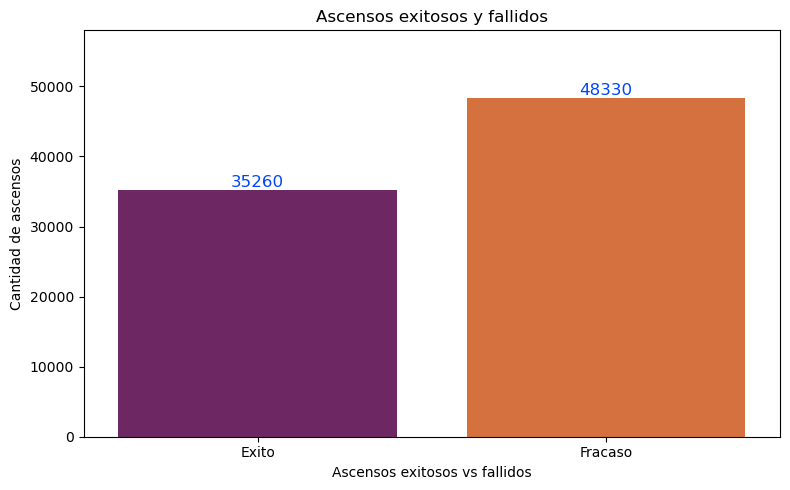

In [39]:
# Mapeamos los valores de msuccess a "Éxito" y "Fracaso", obtenemos un pandas.Series:
resultado = (df_clean["msuccess"]
             .map({True: "Exito", False: "Fracaso"}).fillna("Desconocido")) # No necesario, ya limpiamos nulos.

total_attemps = resultado.value_counts().astype("Int64")
# Pasamos el ratio de intentos totales a porcentaje:
percentages = (total_attemps / total_attemps.sum() * 100).round(2)

df_summary_msuccess = (
    pd.DataFrame({"Ascensos": total_attemps, "Porcentaje": percentages})
    .reindex(["Exito", "Fracaso", "Desconocido"])
    .dropna(how="all") # No debería haber nulos, pero por si acaso
)
display(df_summary_msuccess)

plot_df = df_summary_msuccess.reset_index()
plot_df.columns = ["Resultado", "Ascensos", "Porcentaje"]
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=plot_df, x="Resultado", y="Ascensos",
            hue="Resultado", ax=ax, palette="inferno", dodge=False)

for container in ax.containers:
    ax.bar_label(container, fontsize=12, color="#0044FF")

ax.set_xlabel("Ascensos exitosos vs fallidos")
ax.set_ylabel("Cantidad de ascensos")
ax.set_title("Ascensos exitosos y fallidos")

max_count = plot_df["Ascensos"].max() # Obtenemos el max value de ascensos, para ajustar el limite
ax.set_ylim(0, max_count * 1.2) if pd.notna(max_count) and max_count > 0 else 0
    
plt.tight_layout()
plt.show()

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

Creamos un objeto Series a partir de df_clean, y lo transformamos a un DF para poder ver las estadísticas de la distribución de la edad de l@s montañistas, y también creamos un gráfico a partir de df_clean con la distribución de sus edades. El gráfico es un histograma con la cantidad de entradas en el eje Y, y la edad correspondiente en el eje X.

,Edad
count,83590
mean,38
std,10
min,12
25%,30
50%,37
75%,45
max,86


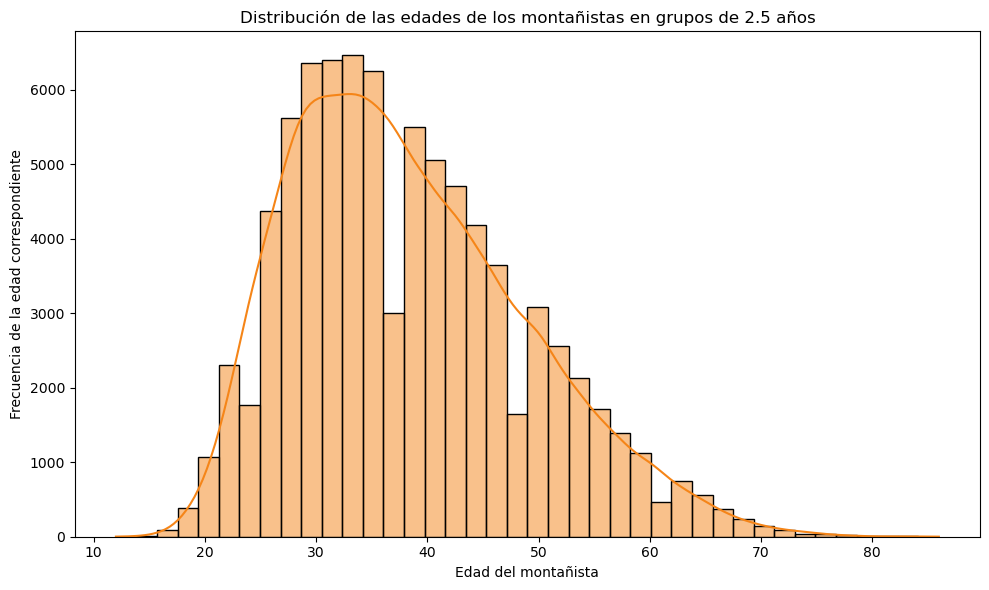

In [40]:
age_summary_df = (df_clean["age"]
               .describe(percentiles=[0.25, 0.5, 0.75])
               .to_frame(name="Edad"))

display(age_summary_df.astype(int))

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df_clean["age"], bins=40, # Grupos de edades de 2.5 años
             kde=True, color="#F58518", ax=ax)

ax.set_xlabel("Edad del montañista")
ax.set_ylabel("Frecuencia de la edad correspondiente")

ax.set_title("Distribución de las edades de los montañistas en grupos de 2.5 años")
plt.tight_layout()
plt.show()

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

Aquí he utilizado un LLM para poder cambiar las entradas por columnas (True y False al usar .unstack sobre la columna de "msuccess")

prompt: mira la celda de mi pregunta 4c, entiendo que debo agrupar para ver los porcentajes de exito y fracaso por cada estación, para ello debemos hacer un conteo, pero luego como puedo manejar las filas de true y false para que queden bien agrupadas??

He cambiado todo el código que me dio el LLM para ajustarlo bien, así que no conservé casi nada del output que me dio, sólo las dos primeras variables, y también la variable season_order, fue generada totalmente por el LLM.

msuccess,Fracaso,Exito,Conteo_Total,Porcentaje_Exito
season,,,,
Spring,22304,18987,41291,45.98
Summer,469,176,645,27.29
Autumn,23923,15606,39529,39.48
Winter,1634,491,2125,23.11


plot_counts with melt en la id_vards season


,season,Resultado,Ascensos
0,Spring,Exito,18987
1,Summer,Exito,176
2,Autumn,Exito,15606
3,Winter,Exito,491
4,Spring,Fracaso,22304
5,Summer,Fracaso,469
6,Autumn,Fracaso,23923
7,Winter,Fracaso,1634


Conteo de ascensos exitosos y fallidos por cada estación:


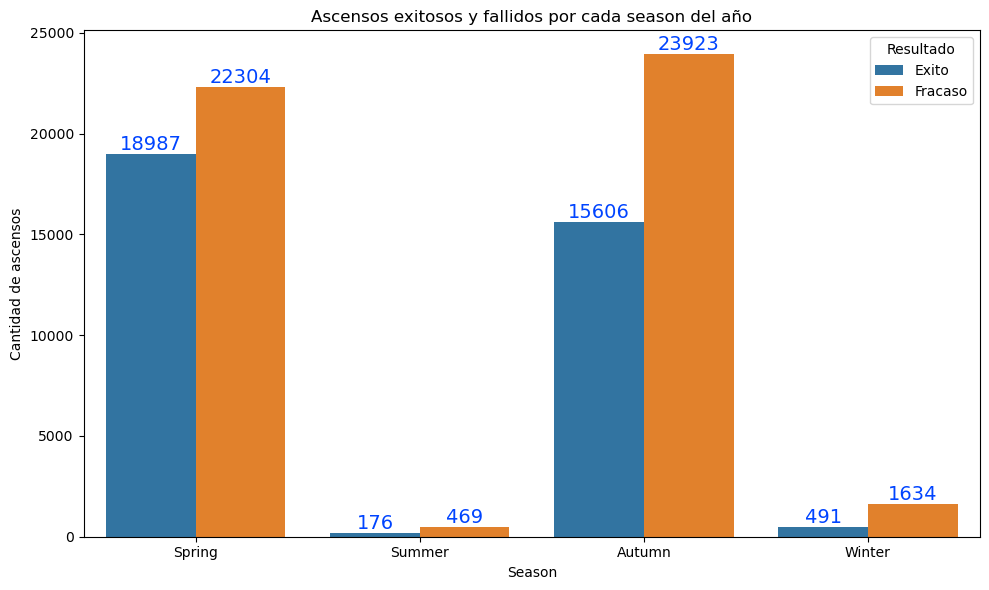

In [41]:
# Conteo de filas por estación y éxito:
count_season_msuccess = df_clean.groupby(["season", "msuccess"], observed=False).size()

season_counting_df = (
    count_season_msuccess
    .unstack(level="msuccess", fill_value=0)
    .rename(columns={True: "Exito", False: "Fracaso"})
)

season_counting_df["Conteo_Total"] = season_counting_df.sum(axis=1)

season_counting_df["Porcentaje_Exito"] = (
    season_counting_df["Exito"] / season_counting_df["Conteo_Total"] * 100).round(2)

# Orden de estaciones generado por LLM:
season_order = [season for season in ["Spring", "Summer", "Autumn", "Winter"] if season in season_counting_df.index]
season_counting_df = season_counting_df.reindex(season_order)

display(season_counting_df)

# Creamos un  DF nuevo para el plot, donde sólo tengamos las columnas Exito y Fracaso:
plot_counts = (
    season_counting_df[["Exito", "Fracaso"]]
    .reset_index() # Reseteamos el indice para que season sea una columna!
    .melt(id_vars="season", var_name="Resultado", value_name="Ascensos")
)

print("plot_counts with melt en la id_vards season")
display(plot_counts)

print("Conteo de ascensos exitosos y fallidos por cada estación:")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_counts, x="season", y="Ascensos", hue="Resultado", ax=ax)
ax.set_xlabel("Season")
ax.set_ylabel("Cantidad de ascensos")
ax.set_title("Ascensos exitosos y fallidos por cada season del año")
ax.legend(title="Resultado")

for container in ax.containers:
    ax.bar_label(container, fontsize=14, color="#0044FF")

plt.tight_layout()
plt.show()

Ahora, hacemos una gráfica similar con el mismo DF, pero esta vez con la columna de Porcentaje_Exito, para responder la última pregunta del enunciado, en este ítem:

In [42]:
display(season_counting_df.head(1))

msuccess,Fracaso,Exito,Conteo_Total,Porcentaje_Exito
season,,,,
Spring,22304,18987,41291,45.98


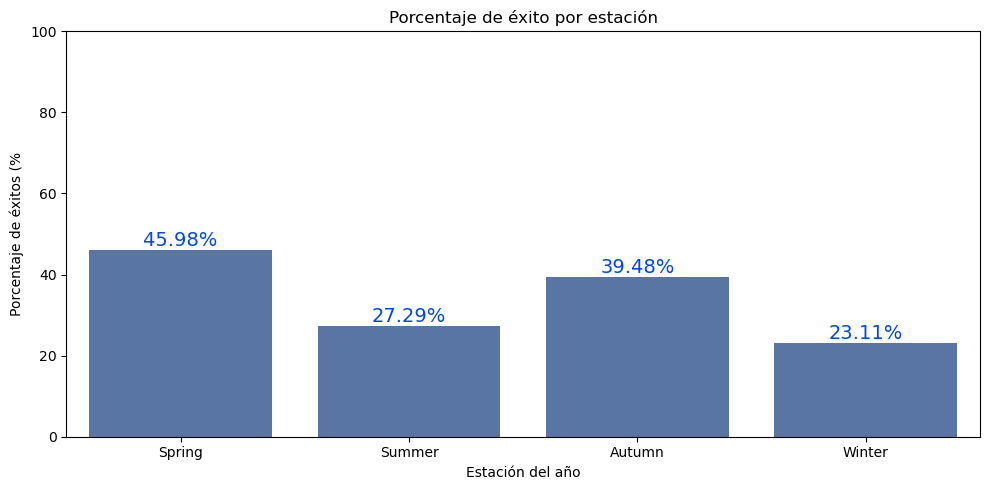

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=season_counting_df, x="season", y="Porcentaje_Exito", color="#4C72B0", ax=ax)
ax.set_xlabel("Estación del año")
ax.set_ylabel("Porcentaje de éxitos (%")
ax.set_title("Porcentaje de éxito por estación")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=14, color="#0044FF")

plt.tight_layout()
plt.show()

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

Basándonos en lo anterior, vamos a crear un DF con la cantidad de ascensos fallidos y exitosos por año, luego graficaremos una gráfica de ascensos totales para ver cómo cambian en el tiempo, y otra gráfica con exitosos y fallidos para diferenciarlos.

msuccess,Fracaso,Exito,Total
year,,,
1905,2,0,2
1907,2,0,2
1909,1,1,2
1910,2,1,3
1920,5,0,5
...,...,...,...
2020,41,184,225
2021,1117,1043,2160
2022,1365,1931,3296


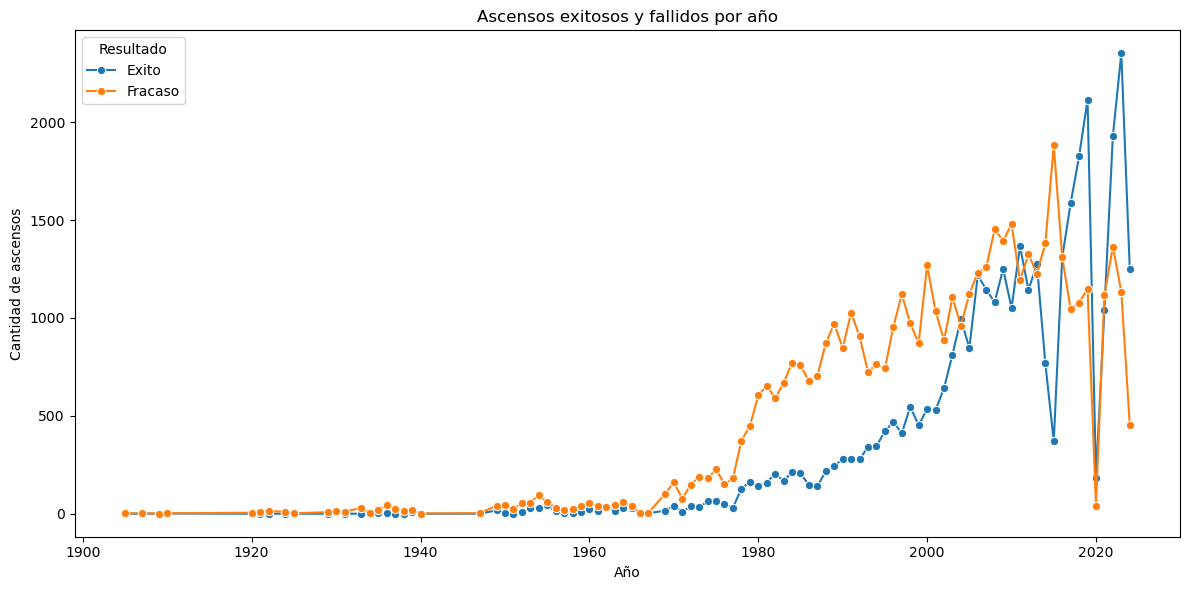

In [44]:
#display(df_clean.head(1))

year_counts = (
    df_clean.groupby(["year", "msuccess"]).size() # Agrupamos y contamos por año y éxito
    # es necesario hacer unstack con fill_value=0, porque hay nulos!
    .unstack(level="msuccess", fill_value=0) # Desapilamos los valores de msuccess y pasamos a columnas
    .rename(columns={True: "Exito", False: "Fracaso"})
    .sort_index() # Ordenamos por año
)

year_counts["Total"] = year_counts.sum(axis=1).astype(int) # Sumamos el total de ascensos por año
display(year_counts)


plot_year = (
    year_counts[["Exito", "Fracaso"]]
    .reset_index() # Reseteamos el indice para que year sea una columna, y así poder graficarla en el eje x
    .melt(id_vars="year", var_name="Resultado", value_name="Ascensos")
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plot_year, x="year", y="Ascensos", hue="Resultado", marker="o", ax=ax)
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de ascensos")
ax.set_title("Ascensos exitosos y fallidos por año")
ax.legend(title="Resultado")
plt.tight_layout()
plt.show()

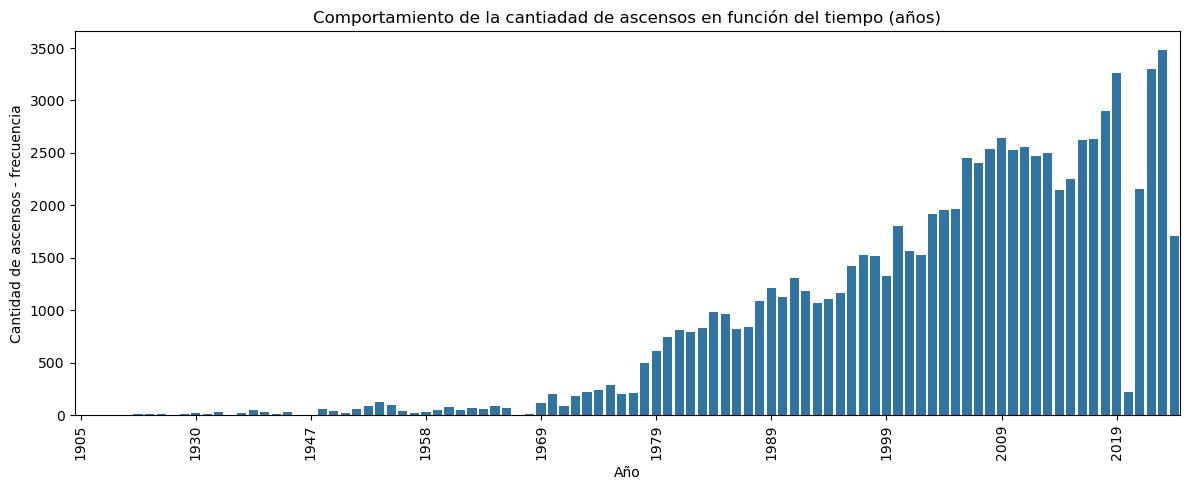

In [45]:
fig, ax = plt.subplots(figsize=(12, 5))
barplot_data = year_counts.reset_index()
sns.barplot(data=barplot_data, x="year", y="Total", ax=ax)
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de ascensos - frecuencia")
ax.set_title("Comportamiento de la cantiadad de ascensos en función del tiempo (años)")


'''Las siguientes particiones fueron producidas con un LLM, porque no pude ajustar bien los ticks del eje x en 
matplotlib, para que mostrara todas las etiquetas de años sin que se solaparan entre ellas. prompt:
haz una particion por años para esta celda, sin usar los indices numericos, sino los valores reales del año.'''

# Ajuste dinámico: mostrar solo una etiqueta cada N años según la cantidad total de años
n_years = len(barplot_data)
if n_years <= 20:
    N = 1
elif n_years <= 50:
    N = 5
elif n_years <= 100:
    N = 10
else:
    N = 50
# Forzar que matplotlib use las etiquetas reales de 'year' (no posiciones numéricas 0..n)
labels = barplot_data['year'].astype(str).values
# Dibujamos y luego ajustamos ticks: obtener posiciones y asignar las etiquetas correspondientes
tick_positions = ax.get_xticks()
# A veces el backend devuelve posiciones continuas; hacemos slicing consistente
ax.set_xticks(tick_positions[::N])
ax.set_xticklabels(labels[::N], rotation=90)
plt.tight_layout()
plt.show()

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

,heightm,peak_success_p
heightm,1.000000,-0.332058
peak_success_p,-0.332058,1.000000


La correlación entre la altura vs el porcentaje de éxito es: -0.3320575184520744


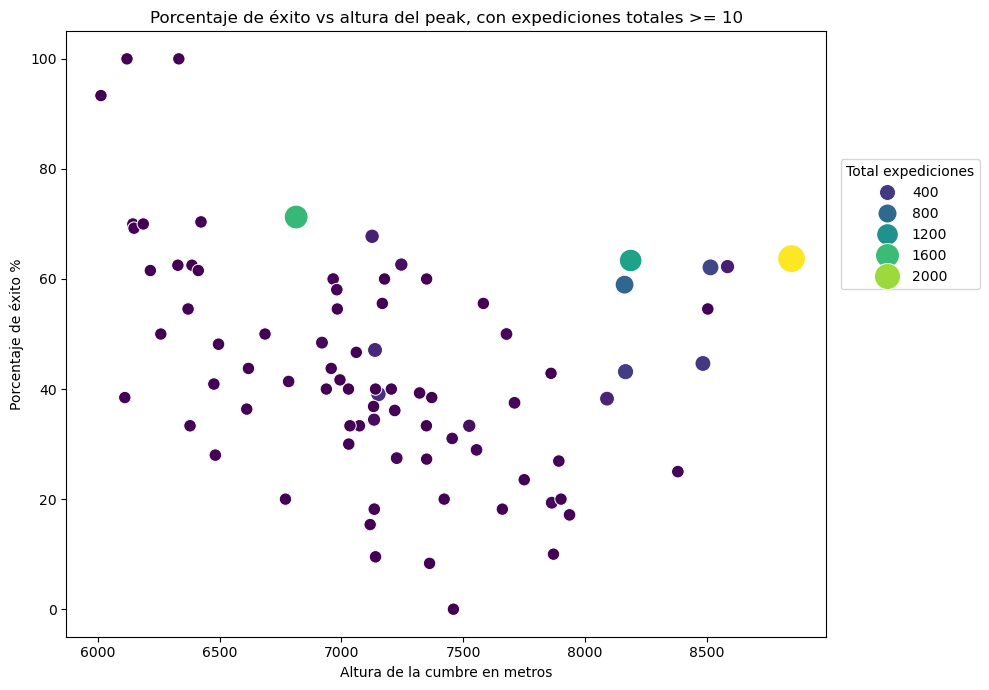

In [46]:
peak_stats = (df_clean[["peakid", "pkname", "heightm", "success_exp", "failed_exp", "peak_success_p"]]
              .drop_duplicates(subset="peakid").copy())

# Creamos la columna de total_expeditions como la suma de success_exp y failed_exp:
peak_stats["total_expeditions"] = peak_stats[["success_exp", "failed_exp"]].sum(axis=1)

# Creamos un nuevo DF filtrando peaks con al menos 10 expediciones, tanto exitosas como fallidas:
filtered_peaks = peak_stats[(peak_stats["total_expeditions"] >= 10)].copy()

# Armamos una correlación entre la altura de cada peak y el porcentaje de éxito de ascenso para cada cumbre:
correlation_df = filtered_peaks[["heightm", "peak_success_p"]].corr()
display(correlation_df)
correlation_value = correlation_df.loc["heightm", "peak_success_p"] # Seleccionamos la celda específica
print(f"La correlación entre la altura vs el porcentaje de éxito es: {correlation_value}")

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=filtered_peaks, # La data son los peaks filtrados
    x="heightm",
    y="peak_success_p",
    hue="total_expeditions",
    palette="viridis",
    size="total_expeditions",
    sizes=(80, 400),
    ax=ax
)
ax.set_xlabel("Altura de la cumbre en metros")
ax.set_ylabel("Porcentaje de éxito %")
ax.set_title("Porcentaje de éxito vs altura del peak, con expediciones totales >= 10")
ax.legend(title="Total expediciones", bbox_to_anchor=(1.01, 0.8), loc="upper left")

plt.tight_layout()
plt.show()

Como vemos, la correlación es negativa, pero es bastante baja por lo general, eso quiere decir que entre mayor sea la altura de la cumbre, menor es el porcentaje de éxito, pero no de manera muy fuerte, porque el número es negativo pero su magnitud es de aproximadamente 0.33, no es una relación muy fuerte entre estas variables. El scatterplot de la visualización es consistente con lo mencionado aquí.

5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su X (matriz de atributos) e y (etiqueta a predecir) de la siguiente manera:

    X: age, sex, citizen, season, heightm, year, success_exp, failed_exp
    y: msuccess

Luego, realice los pasos a continuación:

5.1 Codificación y normalización (1 pto)

    Codifique todas las columnas categóricas, de manera que su matriz X solo tenga valores numéricos.
    Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
    Normalice sus matrices de atributos. Justifique su método de normalización.


Codifique todas las columnas categóricas, de manera que su matriz X solo tenga valores numéricos:

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer # para transformar columnas específicas
from sklearn.preprocessing import StandardScaler, OneHotEncoder # para variables categóricas y numéricas

features_to_select = ["age", "sex", "citizen", "season", "heightm", "year", "success_exp", "failed_exp"]

# Tomamos el df_clean, seleccionamos todo lo necesario y lo copiamos>
model_data = df_clean[features_to_select + ["msuccess"]].copy()
model_data = model_data.dropna() # Borramos nulos, por si acaso

# Definimos X e y para usar en el entrenamiento del modelo:
X = model_data[features_to_select]
y = model_data["msuccess"]

# Dividimos en columnas categóricas y numéricas, como lo pide el enunciado:
categorical_features = ["sex", "citizen", "season"]
numeric_features = ["age", "heightm", "year", "success_exp", "failed_exp"]

'''Aquí, StandardScaler() normaliza las cols numéricas con media 0 y desviación estándar 1,
mientras que OneHotEncoder() convierte las cols categóricas en variables dummy, donde cada categoría
se representa en una nueva columna binaria que puede ser 0 o 1, todo esto dentro de un ColumnTransformer:'''
preprocessor = ColumnTransformer([
    ("category", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("numeric", StandardScaler(), numeric_features)
]) # Las transformaciones de este preprocessor se aplicarán en dos celdas de código más adelante.

Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30:

stratify tiene sentido aquí porque la variable objetivo es categórica, específicamente es binaria: puede ser exito o fracaso.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                random_state=100, stratify=y)

Normalice sus matrices de atributos. Justifique su método de normalización:

Aquí, se aplica la normalización definida en la variable 'preprocessor', que incluye la función integrada StandardScaler(), lo que hace es normalizar cada variable numérica, tomándola y restándole la media, para luego dividir todo eso por la desviación estándar, lo que nos entrega variables numéricas normalizadas con media 0 y desviación estándar 1, eso es importante porque los modelos son sensibles a la escala en la que representamos los datos, necesitamos llevar todos a una misma medida.

In [49]:
# Aplicar las transformaciones definidas en preprocessor:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Class distribution in train:")
print(y_train.value_counts(normalize=True))

Class distribution in train:
msuccess
False    0.578172
True     0.421828
Name: proportion, dtype: float64


5.2 Creación y entrenamiento de modelos (1 pto)

Cree y entrene los siguientes modelos:

Un clasificador KNN

Un árbol de decisión

Un clasificador de regresión logística

Un clasificador random forest (Opcional)

Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre

Accuracy

Precisión

Recall

Matriz de confusión

https://youtu.be/-IvNzmrcyUM

K nearest neighbours con k=5, utiliza a los 5 vecinos más cercanos para predecir el exito o fracaso de una expedición. En este caso, si la mayoría de los k vecinos fracasó, se predice que la variable objetivo a predecir fracasará. 5 es un número estándar para muchos casos, añadir más casos podría traer mucha complejidad y el modelo podría no predecir bien, lo mismo para menos casos. Parece bastante razonable considerar 5 personas que hayan realizado una expedición para predecir si el próximo fallará o no.

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline

# Creamos un pipeline que preprocesa los datos y aplica KNN
pipe_knn = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pipe_knn.fit(X_train, y_train) # Entrenamos el modelo KNN con k=5

y_pred_knn = pipe_knn.predict(X_test) # Predicciones del modelo KNN

# Probamos las predicciones del modelo y calculamos las métricas:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, pos_label=True, zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, pos_label=True, zero_division=0)
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[True, False])

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precisión:", precision_score(y_test, y_pred_knn, pos_label=True, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn, pos_label=True, zero_division=0))

print("Matriz de confusión:")
display(pd.DataFrame(cm_knn, index=["Valor de exito real", "Valor de fracaso real"],
                     columns=["Predicción de éxito", "Predicción de fracaso"]))


Accuracy: 0.7140806316545041
Precisión: 0.670604725670805
Recall: 0.6332009831726224
Matriz de confusión:


,Predicción de éxito,Predicción de fracaso
Valor de exito real,6698,3880
Valor de fracaso real,3290,11209


Usamos Decision Tree con max_depth = 12, la idea es hacer un arbol donde cada nodo se separe en ramos en base a una pregunta, la cuál es una especie de filtro para cada variable. Por ejemplo, si la edad es mayor o menor a cierto valor, se va siguiendo el camino por una u otra rama, así hasta llegar a la predicción, que en este caso es True o False; éxito o fracaso.

Se eligió una división máxima de 12 en max_depth porque así el modelo tiene un equilibrio entre patrones complejos y simples, con una mayor capacidad de generalización que uno con max_depth=5 u 8, pero con mejores resultados, por lo que he estado probando. También sería buena idea poner este hiperparámetro como un número cercano a 10.

El hiperparámetro random_state=100 del modelo se agrega para permitir reproductibilidad de resultados.

In [51]:
from sklearn.tree import DecisionTreeClassifier

pipe_tree = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=12, random_state=100))
])

pipe_tree.fit(X_train, y_train) # Entrenamos el modelo

y_pred_tree = pipe_tree.predict(X_test) # Predicciones del modelo

# Probamos las predicciones del modelo y calculamos las métricas:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, pos_label=True, zero_division=0)
recall_tree = recall_score(y_test, y_pred_tree, pos_label=True, zero_division=0)
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=[True, False])

print("Árbol de decisión con max_depth=8")
print("Accuracy:", accuracy_tree)
print("Precisión:", precision_tree)
print("Recall:", recall_tree)

print("Matriz de confusión:")
display(pd.DataFrame(cm_tree, index=["Valor de exito real", "Valor de fracaso real"],
                     columns=["Predicción de éxito", "Predicción de fracaso"]))


Árbol de decisión con max_depth=8
Accuracy: 0.7436296207680344
Precisión: 0.7016230926231898
Recall: 0.6824541501228966
Matriz de confusión:


,Predicción de éxito,Predicción de fracaso
Valor de exito real,7219,3359
Valor de fracaso real,3070,11429


Logistic Regression, con hiperparámetro max_iter=1000 itera 1000 veces para encontrar los pesos (coeficientes) de la función lineal, cuyas variables son las variables del modelo, y cuyo resultado de la función se pasa por una función de activación, en este caso por la función sigmoide, que predice si el resultado es True o False, para esto iteramos mil veces pero el resultado obtenido parece ser peor que los anteriores modelos, aunque bastante parecido. Cambiar el número de iteraciones a 500, 1500 o 2000 no mejora el modelo.

Si iteramos muy pocas veces, la celda lanzará un error porque el modelo no puede converger, y con muchas iteraciones no habrá mucha diferencia en los resultados.

El hiperparámetro random_state=100 del modelo se agrega para permitir reproductibilidad de resultados.

In [52]:
from sklearn.linear_model import LogisticRegression

pipe_log = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=100))
])

pipe_log.fit(X_train, y_train) # Entrenamos el modelo

y_pred_log = pipe_log.predict(X_test)  # Predicciones del modelo

# Probamos las predicciones del modelo y calculamos las métricas:
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log, pos_label=True, zero_division=0)
recall_log = recall_score(y_test, y_pred_log, pos_label=True, zero_division=0)
cm_log = confusion_matrix(y_test, y_pred_log, labels=[True, False])

print("Regresión logística con max_iter=1000")
print("Accuracy:", accuracy_log)
print("Precisión:", precision_log)
print("Recall:", recall_log)

print("Matriz de confusión:")
display(pd.DataFrame(cm_log, index=["Valor de exito real", "Valor de fracaso real"],
                     columns=["Predicción de éxito", "Predicción de fracaso"]))

Regresión logística con max_iter=1000
Accuracy: 0.6957371296407067
Precisión: 0.6758530183727034
Recall: 0.5355454717337871
Matriz de confusión:


,Predicción de éxito,Predicción de fracaso
Valor de exito real,5665,4913
Valor de fracaso real,2717,11782


Random Forest con hiperparámetro n=100 utiliza n árboles de decisión sobre subconjuntos aleatorios del dataset. La idea es que cada árbol "vota", y con la clase más votada entre los subconjuntos, el modelo clasifica el target. Utilizamos 100 en este hiperparámetro porque nos dio mejores resultados que 50 o 200, un número muy chico puede dar resultados muy variables porque cada arbol toma un subconjunto aleatorio, y puede introducir inestabilidad al modelo, mientras que un número muy grande tarda demasiado en procesar, y mayor complejidad para tan pocas variables no conviene, no se obtienen mejores resultados necesariamente.

n_jobs=-1 hace uso de todos los núcleos del CPU que tenemos disponibles.

El hiperparámetro random_state=100 del modelo se agrega para permitir reproductibilidad de resultados.

In [53]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=100, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)  # Entrenamos el modelo
y_pred_rf = pipe_rf.predict(X_test)  # Predicciones del modelo

# Probamos las predicciones del modelo y calculamos las métricas:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label=True, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=True, zero_division=0)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[True, False])

print("Random Forest (n_estimators=200)")
print("Accuracy:", accuracy_rf)
print("Precisión:", precision_rf)
print("Recall:", recall_rf)

print("Matriz de confusión:")
display(pd.DataFrame(cm_rf, index=["Valor de exito real", "Valor de fracaso real"],
                     columns=["Predicción de éxito", "Predicción de fracaso"]))

Random Forest (n_estimators=200)
Accuracy: 0.7466204091398493
Precisión: 0.706532368472521
Recall: 0.6830213650973719
Matriz de confusión:


,Predicción de éxito,Predicción de fracaso
Valor de exito real,7225,3353
Valor de fracaso real,3001,11498


5.3 Análisis de resultados (0.5 pts)

Interprete, analice y comente sus resultados.

¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro?

¿Fue posible construir un predictor efectivo? Justique.


Sólo la siguiente celda de código fue generada con un LLM, sirve sólo para mostrar los outputs de las celdas anteriores de una sola vez, prompt: "haz una celda simple solo para ver las metricas de las 4 celdas anteriores con un bucle for para cada modelo"

In [54]:
for name, model in [("KNN:\n", pipe_knn),
                    ("Decision Tree:\n", pipe_tree),
                    ("Logistic Regression:\n", pipe_log),
                    ("Random Forest:\n", pipe_rf)]:
    
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precisión:", precision_score(y_test, y_pred, pos_label=True, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, pos_label=True, zero_division=0))
    
    print("Matriz de confusión:")
    cm = confusion_matrix(y_test, y_pred, labels=[True, False])
    display(pd.DataFrame(cm, index=["Valor de exito real", "Valor de fracaso real"],
                         columns=["Predicción de éxito", "Predicción de fracaso"]))


KNN:

Accuracy: 0.7140806316545041
Precisión: 0.670604725670805
Recall: 0.6332009831726224
Matriz de confusión:


,Predicción de éxito,Predicción de fracaso
Valor de exito real,6698,3880
Valor de fracaso real,3290,11209



Decision Tree:

Accuracy: 0.7436296207680344
Precisión: 0.7016230926231898
Recall: 0.6824541501228966
Matriz de confusión:


,Predicción de éxito,Predicción de fracaso
Valor de exito real,7219,3359
Valor de fracaso real,3070,11429



Logistic Regression:

Accuracy: 0.6957371296407067
Precisión: 0.6758530183727034
Recall: 0.5355454717337871
Matriz de confusión:


,Predicción de éxito,Predicción de fracaso
Valor de exito real,5665,4913
Valor de fracaso real,2717,11782



Random Forest:

Accuracy: 0.7466204091398493
Precisión: 0.706532368472521
Recall: 0.6830213650973719
Matriz de confusión:


,Predicción de éxito,Predicción de fracaso
Valor de exito real,7225,3353
Valor de fracaso real,3001,11498


**Explicación 5.3**: Con `metrics_summary` se identifica qué algoritmo lidera cada métrica. Si, por ejemplo, el random forest obtiene el mayor accuracy pero la regresión logística ofrece mejor recall, significa que los modelos priorizan distintos tipos de error. El análisis debe enfocarse en la matriz de confusión asociada: un recall alto implica pocos falsos negativos (ascensos exitosos mal clasificados), mientras que una precisión alta reduce falsos positivos. Dependiendo del objetivo del proyecto (anticipar fracasos o confirmar éxitos) se elige el modelo más conveniente.

¿Qué tendencias puede observar? 
- Los modelos "lineales", como los de regresión logística y KNN (basado en distancias, similar a los de clustering), se ve que producen peor resultado que los no lineales, probablemente se deba a que no se captan relaciones más complejas entre las variables, mientras que los modelos no lineales sí, ya que son mejores para captar modelos complejos, en éstos se mejora la accuracy y recall.

¿Se diferencian de alguna forma las predicciones entre un modelo y otro?
- Sí, pero no por mucho, las predicciones de los modelos no lineales son mejores en generalización y producen mejores resultados, el mejor de ellos parece ser Random Forest, con una accuracy de casi 0.75, una precisión de 0.7 y un recall de 0.68. La regresión logística es la que obtiene peores resultados, con una alta tasa de predicción errónea de valores de éxito, de casi 5000, muy distante de las matrices de confusión de los otros modelos, donde ese valor es más cercano a 3000. En los demás modelos, no se ven muchas diferencias en las predicciones.

¿Fue posible construir un predictor efectivo? Justique.
- Si hicieramos una predicción aleatoria, obtendríamos peores resultados. La forma de validar si un modelo tiene sustento estadístico es comparar los resultados con una distribución aleatoria o modelo base, en este caso vemos que los resultados de accuracy, precisión y recall son del 70%, cercanos a ese valor, o incluso superior. Mientras más cerca del 100% o, en su representación decimal, mientras más cerca del valor 1 estemos, mejor serán las predicciones (formalmente clasificaciones en estos modelos). Los resultados aleatorios deberían ser sercanos al 50% (0.5 en las métricas), por lo que nuestros modelos son capaces de predecir efectivamente la variable objetivo, que es el éxito o fracaso de la expedición evaluada.
